# ROAD ACCIDENT PRONE ZONE IDENTIFICATION SYSTEM

This project aims to analyze road accident data and predict high-risk regions using machine learning.

The system follows these steps:
1. Data Preprocessing 
2. Clustering (Hotspot Detection)
3. Feature Selection
4. Model Training (Random Forest)
5. Model Evaluation
6. Visualization of Results

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN


from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## Data collection

The dataset contains accident data for different states of India.
It includes causes of accidents for the years 2014 and 2016.

In [3]:
df = pd.read_csv("road_accident.csv")
df.head()


,index,sno,stateut,region,regionid,alcintake2014,overspeed2014,overtaking2014,lanejumping2014,wrongside2014,...,asleep2014,othercause2014,alcintake2016,overspeed2016,signalavoid2016,wrongside2016,lanejumping2016,overtaking2016,asleep2016,othercause2016
0,0,1,Andhra Pradesh,south,2,594,12747.0,507,328,668,...,154,1938,128,17286,40,667,325,1024,306,2868
1,1,2,Arunachal Pradesh,northeast,5,11,16.0,0,0,0,...,0,22,15,45,0,7,11,8,8,18
2,2,3,Assam,northeast,5,613,4596.0,129,104,156,...,3,628,352,3520,64,334,156,371,3,873
3,3,4,Bihar,north,1,1680,1496.0,278,236,308,...,72,439,593,2323,8,458,156,573,122,612
4,4,5,Chhattisgarh,centre,9,335,6720.0,188,313,266,...,81,520,145,6660,62,410,175,467,144,953


## Data Preprocessing

1. Handle missing values
2. Remove unnecessary columns
3. Prepare dataset for analysis

In [4]:
df.replace('', np.nan, inplace=True) # Replace blank values with NaN
df = df.dropna() # Remove missing values

In [5]:
df.columns = df.columns.str.strip() # Clean column names

df = df.drop(['index', 'sno'], axis=1, errors='ignore') # Drop unnecessary columns

## Encoding Categorical Data

State and region are categorical values.
They are converted into numeric format using Label Encoding.

In [6]:
le = LabelEncoder()
df['stateut'] = le.fit_transform(df['stateut'])
df['region'] = le.fit_transform(df['region'])

df = df.apply(pd.to_numeric)

## Feature Engineering

Calculating total accidents for 2016 and creating a target variable(risk).
Risk=1 (High Risk)
Risk=2 (Low Risk)

In [7]:
df['total_accidents_2016'] = (
    df['alcintake2016'] + df['overspeed2016'] + df['signalavoid2016'] +
    df['wrongside2016'] + df['lanejumping2016'] + df['overtaking2016'] +
    df['asleep2016'] + df['othercause2016']
)

In [8]:
# Convert into classification problem
df['risk'] = np.where(df['total_accidents_2016'] > df['total_accidents_2016'].median(), 1, 0)

## Clustering (Hotspot Detection)

Two clustering algorithms are applied to identify accident prone zones.
1. K-Means Clustering: It groups data into a fixed number of clusters and helps identify general patterns in accident data.
2. DBSCAN (Density-Based clustering): It identifies dense regions where accidents occur frequently and can detect noise as well as outliers (low dense areas). It does not require specifying number of clusters in advance.

In [9]:
cluster_features = [
    'alcintake2014', 'overspeed2014', 'signalavoid2014',
    'wrongside2014', 'lanejumping2014', 'overtaking2014',
    'asleep2014', 'othercause2014'
]


In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[cluster_features])

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_data)

In [12]:
dbscan = DBSCAN(eps=1.5, min_samples=2)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_data)

## Visualization of Clusters

This graph shows accident hotspots based on 2014 data.

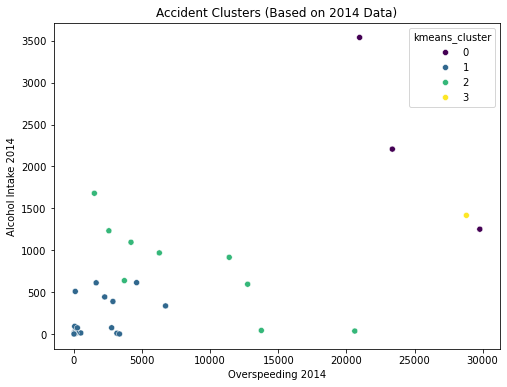

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['overspeed2014'], 
    y=df['alcintake2014'], 
    hue=df['kmeans_cluster'],
    palette='viridis'
)
plt.title("Accident Clusters (Based on 2014 Data)")
plt.xlabel("Overspeeding 2014")
plt.ylabel("Alcohol Intake 2014")
plt.show()


## Feature Selection

We use 2014 data to predict 2016 risk. This avoids data leakage.

In [14]:
features = [
    'overspeed2014',
    'overtaking2014',
    'lanejumping2014',
    'wrongside2014'
]

X = df[features]
y = df['risk']


## Train-Test Split

This dataset is divided into training and testing sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


## Model Training

Random Forest is used for classification.

In [24]:
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=42
)


model.fit(X_train, y_train)


RandomForestClassifier(max_depth=3, n_estimators=50, random_state=42)

## Cross Validation

Used to evaluate model stability.

In [17]:
scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())


Cross-validation scores: [1.         0.85714286 1.         0.85714286 1.        ]
Mean CV accuracy: 0.9428571428571428


## Model Evaluation

In [18]:
y_pred = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.8181818181818182
Precision: 0.8
Recall: 0.8
F1 Score: 0.8


## Confusion Matrix

It is used to evaluate the performance of the classification model.

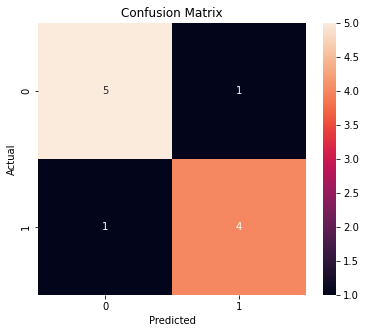

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Classification Report

It provides detailed evaluation of the model performance for both classes (Low risk=0 and High risk=1).

In [21]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.80      0.80      0.80         5

    accuracy                           0.82        11
   macro avg       0.82      0.82      0.82        11
weighted avg       0.82      0.82      0.82        11



## Feature Importance

It shoes how much each input variable contributes to the model's prediction.

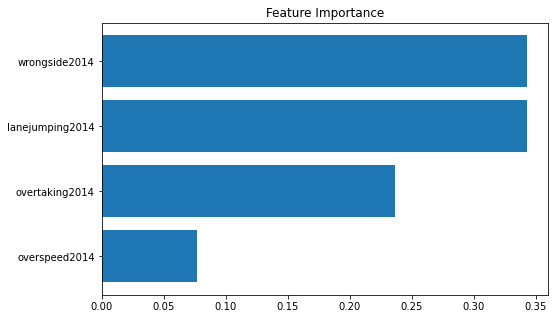

In [22]:
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()


## Conclusion

The model achieves around 80% accuracy in predicting accident prone areas.
Precision is high, means predicted high-risk zones are reliable.

The combination of clustering and machine learning improves prediction performance.

In [23]:
import pickle

# Save model
pickle.dump(model, open("model.pkl", "wb"))

In [ ]:
import os
import pickle

# Check current path
print("Saving model in:", os.getcwd())

# DELETE old model first (important)
if os.path.exists("model.pkl"):
    os.remove("model.pkl")
    print("Old model deleted")

# Save new model
pickle.dump(model, open("model.pkl", "wb"))

print("✅ New model saved")


In [ ]:
import sklearn
print(sklearn.__version__)


In [ ]:
import os

if os.path.exists("model.pkl"):
    os.remove("model.pkl")


In [ ]:
!pip install -U scikit-learn --user
